In [1]:
"""

Exploring how to plot the gain modulation due to the autapse

1) plot F-inst/steady versus I for each neuron type.


"""

import sys
sys.path.append("..//")

from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pickle
import random


from simulation import get_F

In [2]:
# import data

out_dir = './/RS_mid//'

filename = "RS_mid_test.pickle"
with open(filename, 'rb') as file:
    df = pickle.load(file)

print(df.keys())

Index(['e', 'f', 'tau', 'I_h', 'F_instant', 'F_steady', 'autapse current',
       'autapse delay'],
      dtype='object')


[0.  0.1 0.2 0.5]
[  0.  50. 150. 250.]


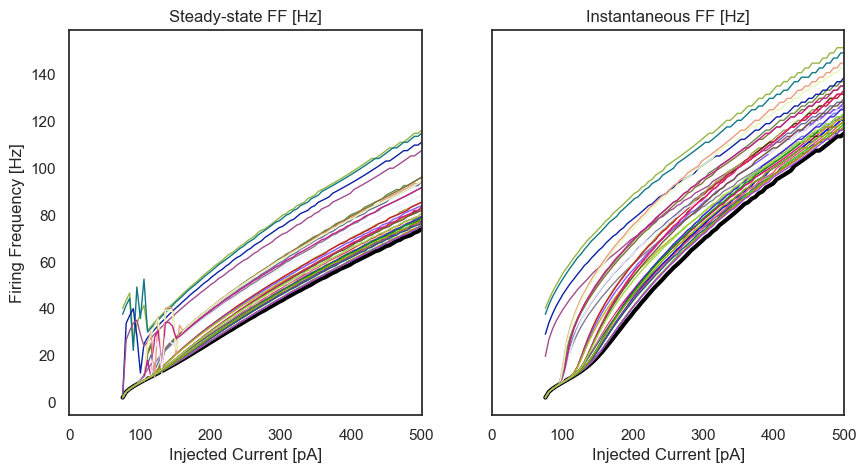

In [3]:
# plot F vs I for each neuron

e_vals = df["e"].unique()
f_vals = df["f"].unique()
tau_vals = df["tau"].unique()

print(e_vals)
print(f_vals)
fig, ax = plt.subplots(1, 2, figsize = (10, 5), sharey = True)


for e in e_vals:
    for f in f_vals:
        for tau in tau_vals:
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)]
            
            if e == 0.0 and f == 0.0 and tau == 0.0:
                colour = (0., 0., 0.)
                linewidth = 3
            else:
                colour = tuple(np.random.rand(3))   # colour for individual neurons
                linewidth = 1
            #plot F_steady
            ax[0].plot(sub_df['I_h'], sub_df['F_steady'], c = colour, linewidth = linewidth)
            # plot F_instant
            ax[1].plot(sub_df['I_h'], sub_df['F_instant'], c = colour, linewidth = linewidth)

ax[0].set_xlabel('Injected Current [pA]')
ax[1].set_xlabel('Injected Current [pA]')
ax[0].set_xlim(df.min(axis = 0)['I_h'], df.max(axis = 0)['I_h'])
ax[1].set_xlim(df.min(axis = 0)['I_h'], df.max(axis = 0)['I_h'])
#ax[0].set_xlim(df.min(axis = 0)['I_h'], 200)
#ax[1].set_xlim(df.min(axis = 0)['I_h'], 200)

ax[0].set_ylabel('Firing Frequency [Hz]')

ax[0].set_title("Steady-state FF [Hz]")
ax[1].set_title("Instantaneous FF [Hz]")

plt.savefig(out_dir + "I-O_gain_modulation.png")


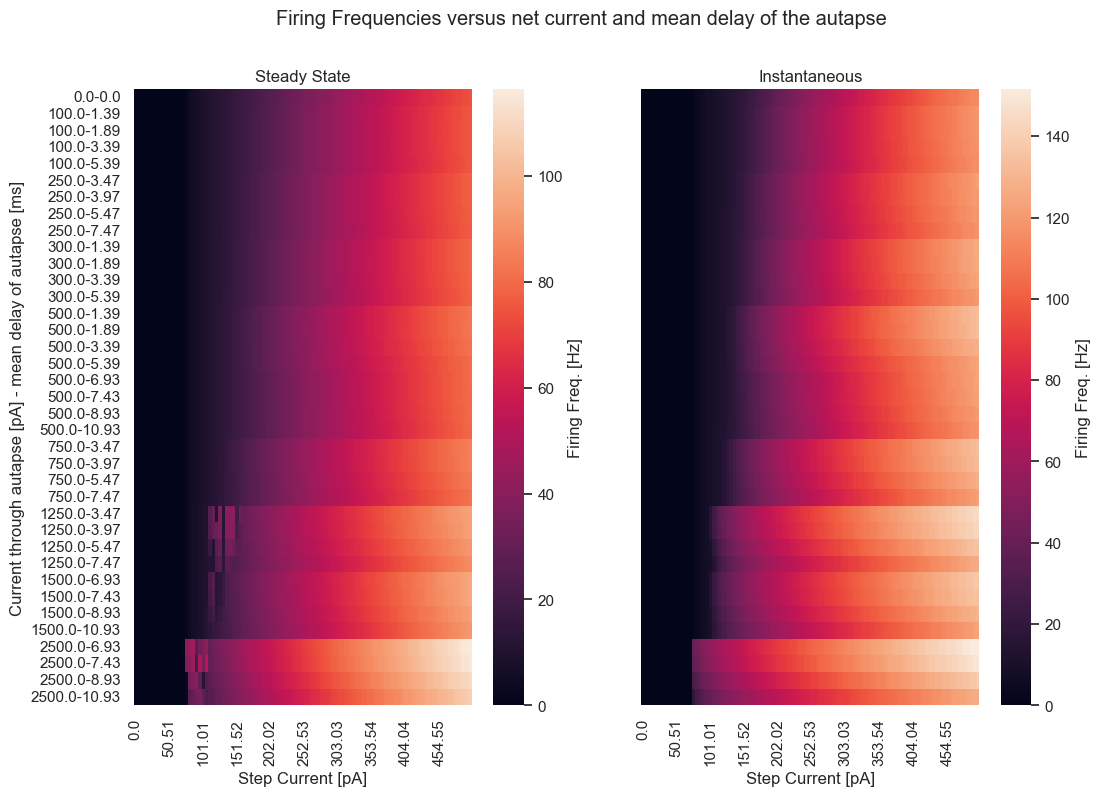

In [4]:
# plot heatmap of F-steady/instant versus autapse current and delay...

"""

From the plots, it seems these metrics might be sufficient to differentiate the different behavioural regimes?
These may serve then as a lower-dimensional interpretation of our results...

"""

fig, ax = plt.subplots(1, 2, figsize = (12, 8), sharey = True)

temp_df = df.copy()

#temp_df['temp_id'] = temp_df.groupby(['autapse delay', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)


steady_df = (temp_df.pivot(index = ['autapse current', 'autapse delay'], columns = 'I_h', values = 'F_steady'))
instant_df = (temp_df.pivot(index = ['autapse current', 'autapse delay'], columns = 'I_h', values = 'F_instant'))

sns.heatmap(steady_df, annot = False, linewidth = 0., ax = ax[0], xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'})
sns.heatmap(instant_df, annot = False, linewidth = 0., ax = ax[1], xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'})

ax[0].set_xlabel('Step Current [pA]')
ax[1].set_xlabel('Step Current [pA]')

ax[0].set_ylabel('Current through autapse [pA] - mean delay of autapse [ms]')
ax[1].set_ylabel('')

ax[0].set_title('Steady State')
ax[1].set_title('Instantaneous')

fig.suptitle('Firing Frequencies versus net current and mean delay of the autapse ')

plt.savefig(out_dir + "frequency_by_net_current.png")

Text(0.5, 0.98, 'Firing Frequencies versus current through the autapse')

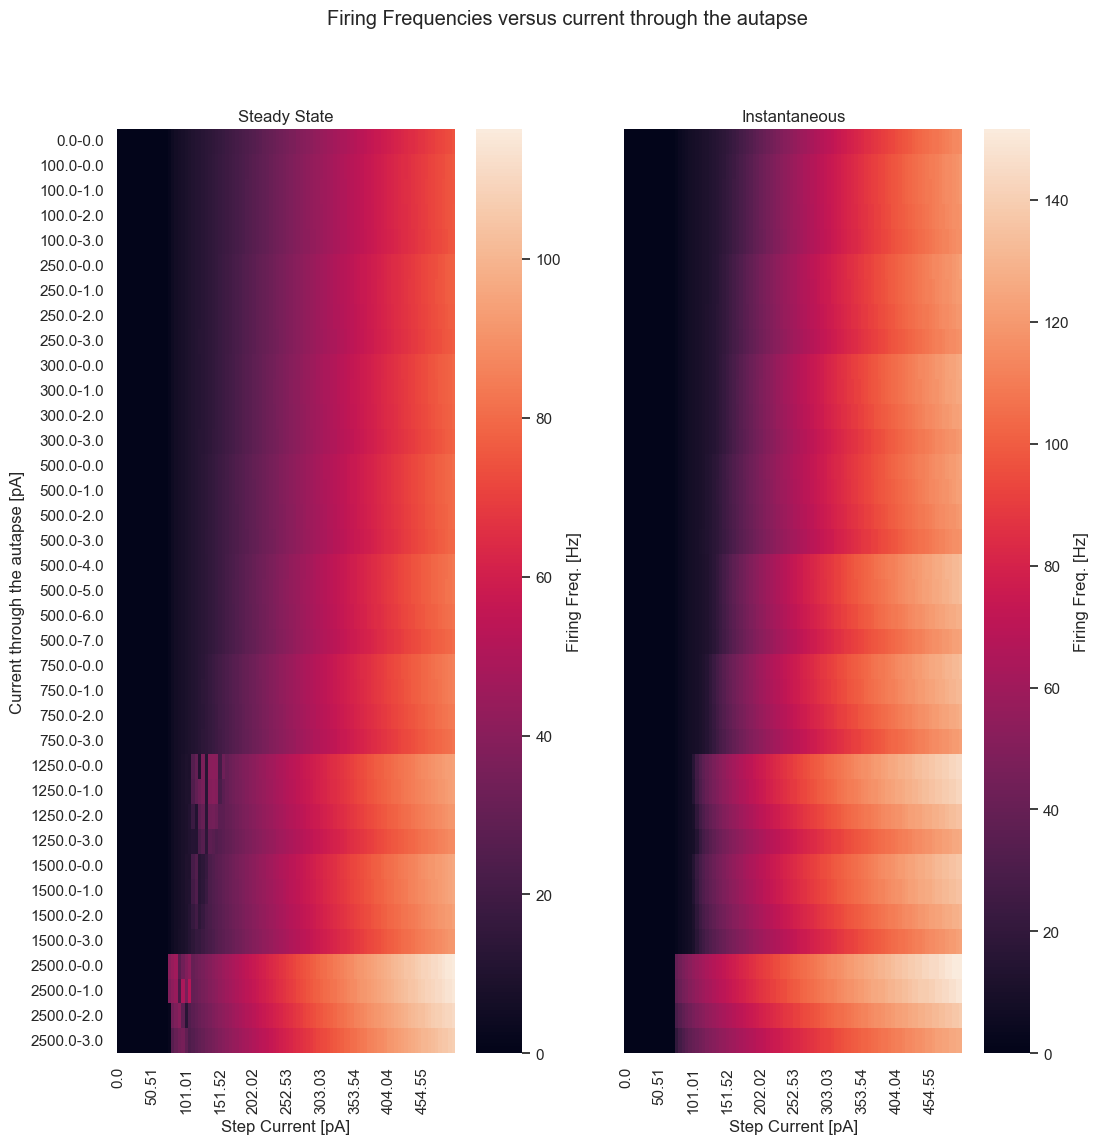

In [5]:
# plot heatmap of F-steady/instant versus net autapse current

fig, ax = plt.subplots(1, 2, figsize = (12, 12), sharey = True)

temp_df = df.copy()

temp_df['temp_id'] = temp_df.groupby(['autapse current', 'I_h']).cumcount()
temp_df = temp_df.round(decimals = 2)
temp_df= temp_df.fillna(0.)


steady_df = (temp_df.pivot(index = ['autapse current', 'temp_id'], columns = 'I_h', values = 'F_steady'))
instant_df = (temp_df.pivot(index = ['autapse current', 'temp_id'], columns = 'I_h', values = 'F_instant'))

sns.heatmap(steady_df, annot = False, linewidth = 0., ax = ax[0], xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'})
sns.heatmap(instant_df, annot = False, linewidth = 0., ax = ax[1], xticklabels = 10, yticklabels = True, cbar_kws = {'label': 'Firing Freq. [Hz]'})

ax[0].set_xlabel('Step Current [pA]')
ax[1].set_xlabel('Step Current [pA]')

ax[0].set_ylabel('Current through the autapse [pA]')
ax[1].set_ylabel('')

ax[0].set_title('Steady State')
ax[1].set_title('Instantaneous')

fig.suptitle('Firing Frequencies versus current through the autapse')

##### Same analysis above ordered by the mean delay of the autapse is not informative.

### Plotting the traces where there are weird results just above threshold

In [7]:
print(df[(df['autapse current'] == 2500.0) & (df['I_h'] == 0.0)])


      e      f  tau  I_h  F_instant  F_steady  autapse current  autapse delay
25  0.1  250.0  0.0  0.0        NaN       NaN           2500.0       6.931472
26  0.1  250.0  0.5  0.0        NaN       NaN           2500.0       7.431472
27  0.1  250.0  2.0  0.0        NaN       NaN           2500.0       8.931472
28  0.1  250.0  4.0  0.0        NaN       NaN           2500.0      10.931472


In [8]:
"""
Plotting for different tau values where net autapse current is 1500 or 1250

RESULTS: seems to be a range where the neuron exhibits tonic bursting!! Right in the middle of the 
physiological range!

"""


params = df[((df['autapse current'] == 1250.0) | (df['autapse current'] == 1500.0)) & (df['I_h'] == 0.0)]

# INTEGRATOR - NEAR RESONATOR TRANSITION

RS_mid = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 0.5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_mid_1500 = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 0.5, 'c': -50, 'd': 100, 'e': 0.1, 'f': 150., 'tau': 0.}
    
RS_mid_1250 = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 0.5, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 0.}



tau_vals = np.array([0., 0.5, 2.0, 4.0])
params_1500 = []
params_1250 = []

for tau in tau_vals:
    temp_param_1500 = RS_mid_1500.copy()
    temp_param_1500['tau'] = tau
    params_1500.append(temp_param_1500)
    
    temp_param_1250 = RS_mid_1250.copy()
    temp_param_1250['tau'] = tau
    params_1250.append(temp_param_1250)

df_1500 = pd.DataFrame(params_1500)
df_1250 = pd.DataFrame(params_1250)


T = 1000
dt = 0.1
N_iter = int(T/dt)

batch_1500 = batchAQUA(df_1500)
batch_1250 = batchAQUA(df_1250)

x_start = np.full((len(tau_vals), 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(len(tau_vals))

batch_1500.Initialise(x_start, t_start)
batch_1250.Initialise(x_start, t_start)

# define injected current 
I_h = 130
I_inj = np.array([step_current(N_iter, dt, 0.0, 100, I_h) for tau in tau_vals])

# simulate
X_1500, T, spikes_1500 = batch_1500.update_batch(dt, N_iter, I_inj)
X_1250, T, spikes_1250 = batch_1250.update_batch(dt, N_iter, I_inj)


  0%|          | 0/9999 [00:00<?, ?it/s]

100%|██████████| 9999/9999 [00:02<00:00, 4853.87it/s]


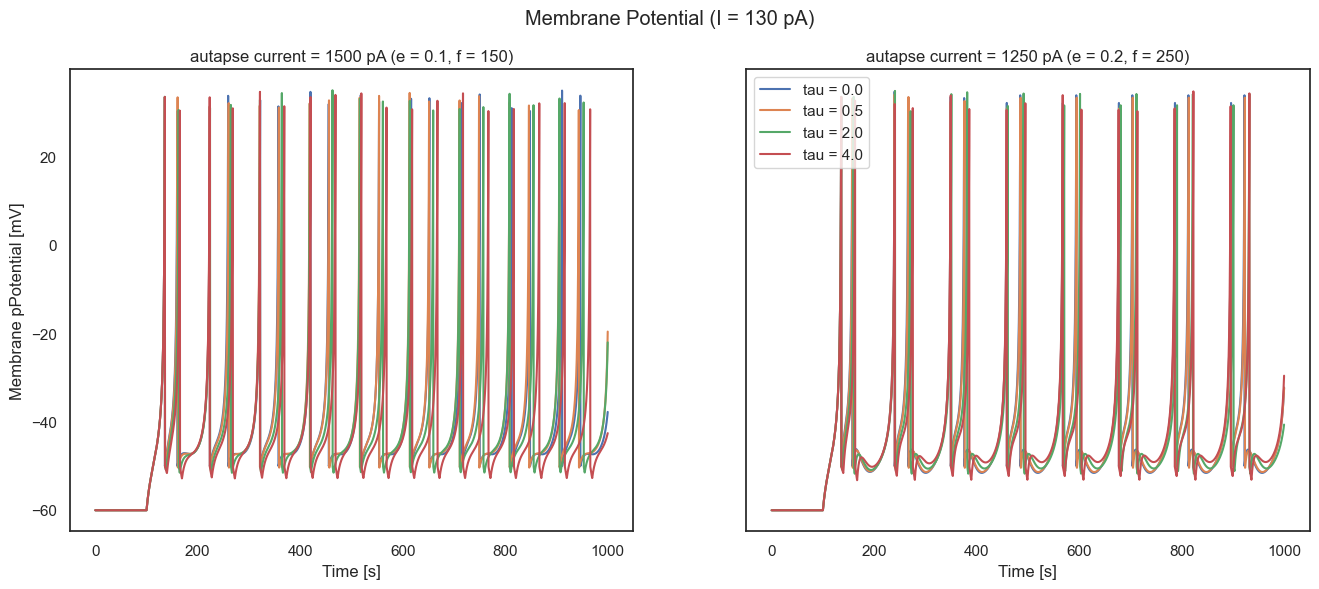

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)

for i in range(len(tau_vals)):
    label = f"tau = {tau_vals[i]}"
    ax[0].plot(T, X_1500[i, 0, :], label = label)
    ax[1].plot(T, X_1250[i, 0, :], label = label)

ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Membrane pPotential [mV]")

ax[1].set_xlabel('Time [s]')

ax[0].set_title('autapse current = 1500 pA (e = 0.1, f = 150)')
ax[1].set_title('autapse current = 1250 pA (e = 0.2, f = 250)')

fig.suptitle(f"Membrane Potential (I = {I_h} pA)")
plt.legend()

plt.savefig(out_dir + "membrane_potentials_diffTau.png")

In [10]:
"""
Now 2 sets of identical neurons with different driving frequencies


"""


params = df[((df['autapse current'] == 1250.0) | (df['autapse current'] == 1500.0)) & (df['I_h'] == 0.0)]

RS_mid = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 0.5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_mid_1500 = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 0.5, 'c': -50, 'd': 100, 'e': 0.1, 'f': 150., 'tau': 0.}
    
RS_mid_1250 = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 0.5, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 0.}


params_1500 = []
params_1250 = []

I_range = np.linspace(100, 160, 5)

for I in I_range:
    params_1500.append(RS_mid_1500)
    params_1250.append(RS_mid_1250)


df_1500 = pd.DataFrame(params_1500)
df_1250 = pd.DataFrame(params_1250)

#sim params
T = 1000
dt = 0.1
N_iter = int(T/dt)

batch_1500 = batchAQUA(df_1500)
batch_1250 = batchAQUA(df_1250)

x_start = np.full((len(I_range), 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(len(I_range))

batch_1500.Initialise(x_start, t_start)
batch_1250.Initialise(x_start, t_start)

# define injected current 
I_inj = np.array([step_current(N_iter, dt, 0.0, 100, i) for i in I_range])

# simulate
X_1500, T, spikes_1500 = batch_1500.update_batch(dt, N_iter, I_inj)
X_1250, T, spikes_1250 = batch_1250.update_batch(dt, N_iter, I_inj)

100%|██████████| 9999/9999 [00:01<00:00, 6300.45it/s]


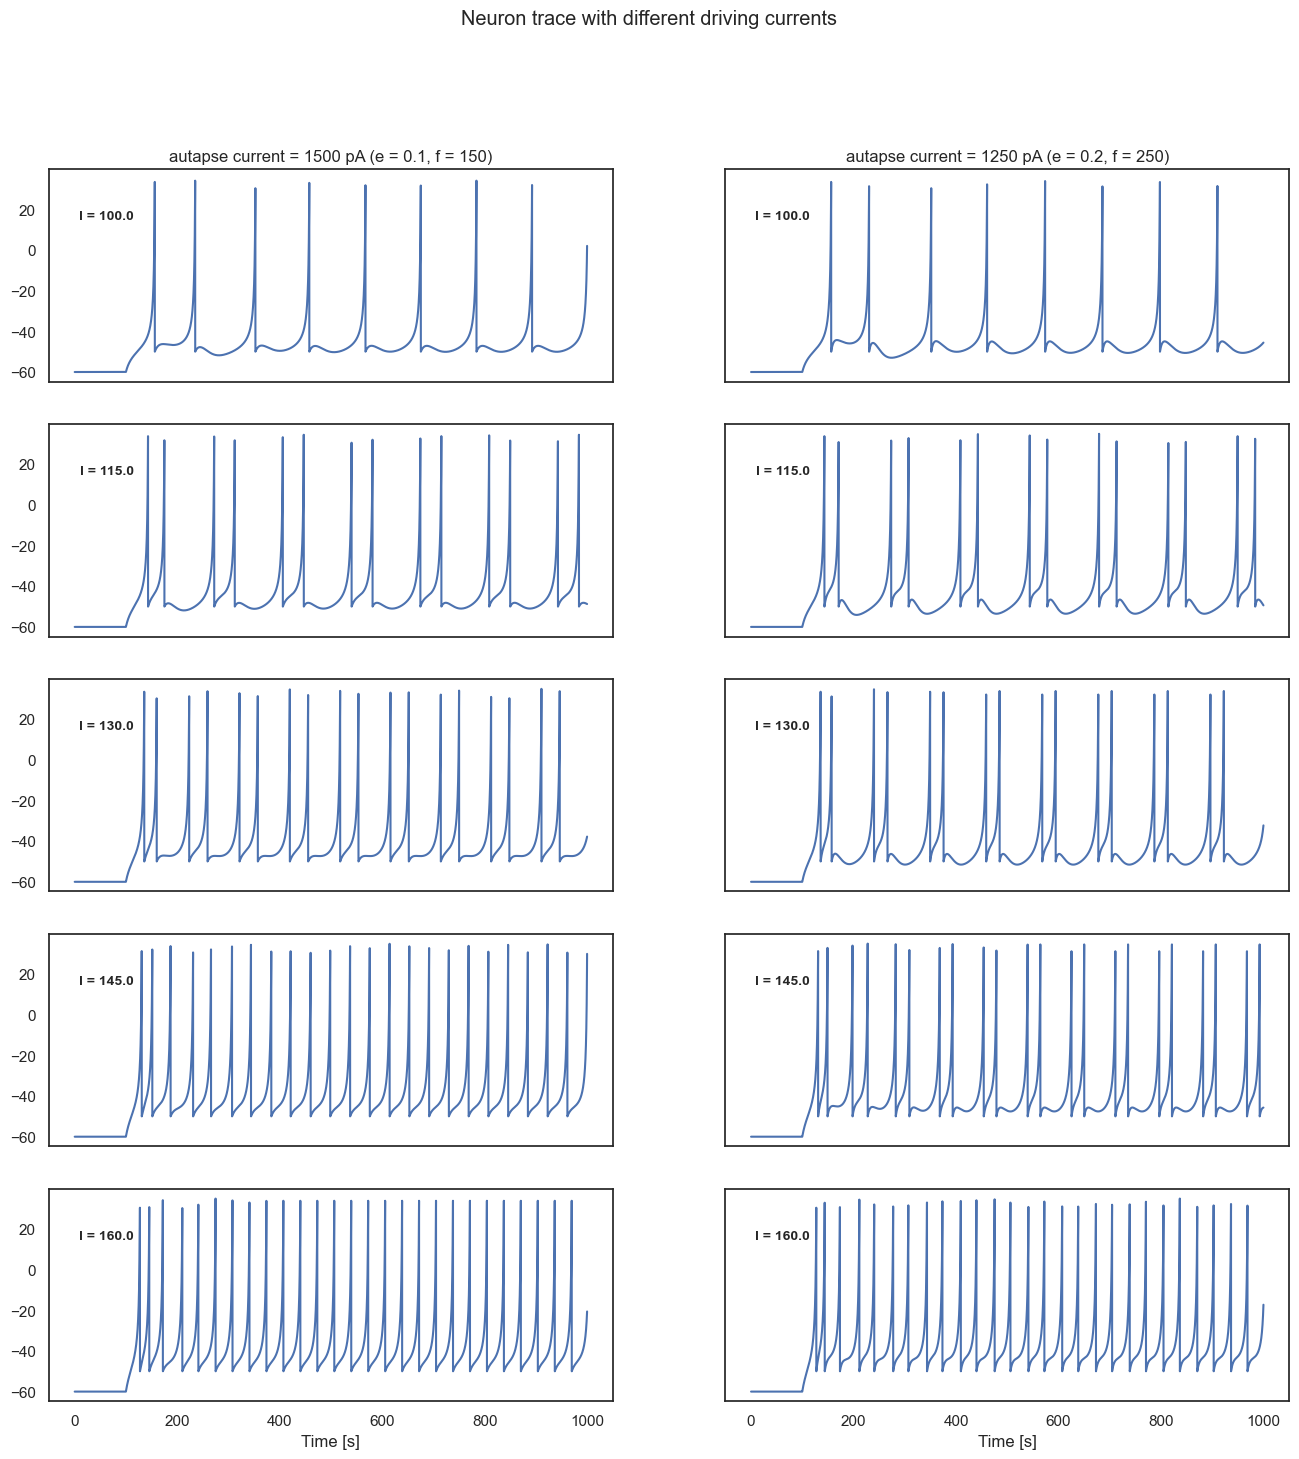

In [11]:
fig, ax = plt.subplots(len(I_range), 2, figsize = (16, 16), sharey = True, sharex = True)

for n, i in enumerate(I_range):
    label = f"I = {np.round(I_range[n], 0)}"
    ax[n, 0].plot(T, X_1500[n, 0, :], label = label)
    ax[n, 1].plot(T, X_1250[n, 0, :], label = label)

    ax[n, 0].text(0.15, 0.75, label, verticalalignment = 'bottom', horizontalalignment = 'right',
            transform = ax[n, 0].transAxes, fontsize = 10, fontweight = 'bold')
    ax[n, 1].text(0.15, 0.75, label, verticalalignment = 'bottom', horizontalalignment = 'right',
            transform = ax[n, 1].transAxes, fontsize = 10, fontweight = 'bold')
    #ax[n, 0].set_ylabel(label)

ax[n, 0].set_xlabel("Time [s]")

ax[n, 1].set_xlabel('Time [s]')

ax[0, 0].set_title('autapse current = 1500 pA (e = 0.1, f = 150)')
ax[0, 1].set_title('autapse current = 1250 pA (e = 0.2, f = 250)')

fig.suptitle("Neuron trace with different driving currents")

plt.savefig(out_dir + "membrane_potentials_diffI.png")